# 12 The Step Size Decides the Total

| | |
|---|---|
| **Path** | Multilayer perceptron |
| **Prerequisite** | 11 |

Keep the hidden features fixed, and step only $(v_1, v_2, c)$. Lesson 11 gave

$$
\nabla = (2,\, 1,\, 1)
$$

and the current weights are $(1,\, -1,\, 0)$. The total loss is $1/2$.

A step of size $\eta$ produces

$$
(v_1, v_2, c) \leftarrow (1 - 2\eta,\, -1 - \eta,\, -\eta)
$$

**Half of one eighth, $\eta = 1/8$.**

$$
v_1 = \dfrac{3}{4}, \quad v_2 = -\dfrac{9}{8}, \quad c = -\dfrac{1}{8}
$$

The four scores become

$$
\begin{aligned}
s(0, 0) &= -\dfrac{1}{8} \\
s(1, 0) &= \dfrac{5}{8} \\
s(0, 1) &= \dfrac{5}{8} \\
s(1, 1) &= \dfrac{1}{4}
\end{aligned}
$$

The total loss is

$$
\dfrac{1}{128} + \dfrac{9}{128} + \dfrac{9}{128} + \dfrac{4}{128} = \dfrac{23}{128}
$$

Since $23/128 < 1/2$, the step helped.

**Twice that size, $\eta = 1/4$.**

$$
v_1 = \dfrac{1}{2}, \quad v_2 = -\dfrac{5}{4}, \quad c = -\dfrac{1}{4}
$$

Gate 11 now scores $-1/2$, and the two pass gates score $1/4$. The total loss is

$$
\dfrac{23}{32}
$$

And $23/32 > 1/2$. The same direction, taken four times farther than $1/8$, raises the loss. Gate 11 got closer to zero, and the three gates that had been exact were pushed off their targets by more than that gain.


## Example 1 — Both step sizes, from the same gradient


In [1]:
# eta 1/8 ends at total loss 23/128. eta 1/4 ends at 23/32, which is worse than 1/2.
from fractions import Fraction

hidden = {
    (0, 0): (0, 0),
    (1, 0): (1, 0),
    (0, 1): (1, 0),
    (1, 1): (2, 1),
}
targets = {(0, 0): 0, (1, 0): 1, (0, 1): 1, (1, 1): 0}

def total(v1, v2, c):
    loss = 0
    scores = []
    for gate, (h1, h2) in hidden.items():
        score = v1 * h1 + v2 * h2 + c
        scores.append(score)
        loss += Fraction(1, 2) * (score - targets[gate]) ** 2
    return scores, loss

start, start_loss = total(1, -1, 0)
small_w = (1 - 2 * Fraction(1, 8), -1 - Fraction(1, 8), -Fraction(1, 8))
large_w = (1 - 2 * Fraction(1, 4), -1 - Fraction(1, 4), -Fraction(1, 4))
small_scores, small_loss = total(*small_w)
large_scores, large_loss = total(*large_w)
print(start_loss)
print(small_w, small_scores, small_loss)
print(large_w, large_scores, large_loss)
assert start_loss == Fraction(1, 2)
assert small_w == (Fraction(3, 4), Fraction(-9, 8), Fraction(-1, 8))
assert small_scores == [Fraction(-1, 8), Fraction(5, 8), Fraction(5, 8), Fraction(1, 4)]
assert small_loss == Fraction(23, 128)
assert large_loss == Fraction(23, 32)
assert small_loss < start_loss < large_loss


1/2
(Fraction(3, 4), Fraction(-9, 8), Fraction(-1, 8)) [Fraction(-1, 8), Fraction(5, 8), Fraction(5, 8), Fraction(1, 4)] 23/128
(Fraction(1, 2), Fraction(-5, 4), Fraction(-1, 4)) [Fraction(-1, 4), Fraction(1, 4), Fraction(1, 4), Fraction(-1, 2)] 23/32


## Example 2 — The same comparison as bar heights

The middle bar is the loss before the step. Green is $\eta = 1/8$. Clay is $\eta = 1/4$.


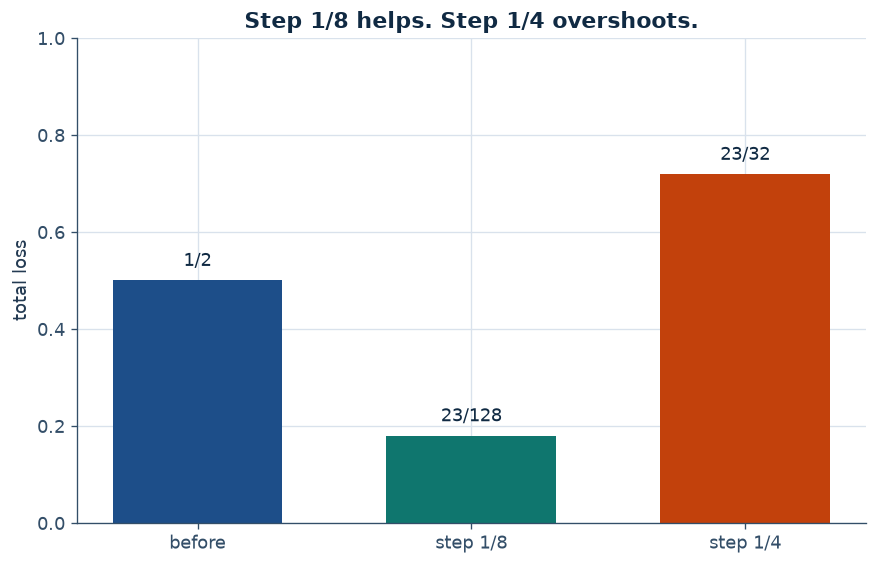

In [2]:
import matplotlib.pyplot as plt

# Pass is green, fail is clay, and the bend or the helpful step is blue or green.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# Bar heights are the three exact losses: 1/2, 23/128, and 23/32.
from fractions import Fraction

losses = [Fraction(1, 2), Fraction(23, 128), Fraction(23, 32)]
fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
bars = ax.bar(
    [0, 1, 2],
    [float(item) for item in losses],
    color=[BLUE, GREEN, CLAY],
    width=0.62,
)
ax.set_xticks([0, 1, 2], ["before", "step 1/8", "step 1/4"])
ax.set_ylim(0, 1)
ax.set_ylabel("total loss")
ax.set_title("Step 1/8 helps. Step 1/4 overshoots.")
for bar, loss in zip(bars, ["1/2", "23/128", "23/32"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        loss,
        ha="center",
        color=INK,
    )


## Pitfall — The trained gate can improve while the table gets worse

Under $\eta = 1/4$, gate 11 moves from score $1$ to score $-1/2$. Its own loss falls from $1/2$ to $1/8$. The total still rises to $23/32$, because gates 00, 10, and 01 leave their perfect scores. A line of output that names only the active gate is not the loss the step is supposed to serve.


In [3]:
# Gate 11 alone improves under eta 1/4. The other three gates pay more than that gain.
from fractions import Fraction

own = Fraction(1, 2) * (Fraction(-1, 2) - 0) ** 2
print(own)
assert own == Fraction(1, 8)
assert own < Fraction(1, 2)
assert Fraction(23, 32) > Fraction(1, 2)


1/8


## Summary

The batch gradient at these weights is $(2, 1, 1)$. Step $1/8$ lowers the total loss from $1/2$ to $23/128$. Step $1/4$ raises it to $23/32$. The far gate's own loss can fall on the step that damages the table.
